### Import Required Libraries

In [1]:
# ==========================================
# HEART DISEASE PREDICTION
# Data Loading & Inspection
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:

df = pd.read_csv("heart_disease_dataset.csv")

In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


### Dataset Shape

In [4]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 16)


### Dataset Information

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

### Display Column Names

In [6]:
# Column names
print(df.columns)

Index(['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Smoking', 'Alcohol Intake', 'Exercise Hours', 'Family History',
       'Diabetes', 'Obesity', 'Stress Level', 'Blood Sugar',
       'Exercise Induced Angina', 'Chest Pain Type', 'Heart Disease'],
      dtype='object')


### Statistical Summary

In [7]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,52.293,15.727126,25.0,39.00,52.0,66.0,79.0
Cholesterol,1000.0,249.939,57.914673,150.0,200.00,248.0,299.0,349.0
Blood Pressure,1000.0,135.281,26.388300,90.0,112.75,136.0,159.0,179.0
Heart Rate,1000.0,79.204,11.486092,60.0,70.00,79.0,89.0,99.0
Exercise Hours,1000.0,4.529,2.934241,0.0,2.00,4.5,7.0,9.0
Stress Level,1000.0,5.646,2.831024,1.0,3.00,6.0,8.0,10.0
Blood Sugar,1000.0,134.941,36.699624,70.0,104.00,135.0,167.0,199.0
Heart Disease,1000.0,0.392,0.488441,0.0,0.00,0.0,1.0,1.0


### Check Missing Values

In [8]:
# Missing values
df.isnull().sum()

Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

In [9]:
# Check the Data Type

In [10]:
df["Alcohol Intake"].dtype

dtype('O')

In [11]:
# View the Unique Values

In [12]:
df["Alcohol Intake"].value_counts(dropna=False)

Alcohol Intake
Heavy       346
NaN         340
Moderate    314
Name: count, dtype: int64

In [13]:
# Decide How to Handle the Missing Values

In [14]:
df["Alcohol Intake"] = df["Alcohol Intake"].fillna(df["Alcohol Intake"].mode()[0])

In [15]:
# Verify

In [16]:
df.isnull().sum()

Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64

In [17]:
df["Alcohol Intake"].value_counts(dropna=False)

Alcohol Intake
Heavy       686
Moderate    314
Name: count, dtype: int64

In [18]:
# Check missing values
print(df["Alcohol Intake"].isnull().sum())

0


In [19]:
# Check unique values including missing values
print(df["Alcohol Intake"].value_counts(dropna=False))

Alcohol Intake
Heavy       686
Moderate    314
Name: count, dtype: int64


In [20]:
df.sample(10, random_state=42)

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
521,77,Female,248,96,72,Current,Moderate,2,No,Yes,Yes,9,97,No,Asymptomatic,1
737,42,Male,293,143,80,Never,Heavy,6,Yes,No,Yes,10,127,No,Non-anginal Pain,0
740,42,Female,206,127,97,Current,Heavy,2,Yes,Yes,Yes,4,163,No,Typical Angina,0
660,40,Female,288,101,84,Never,Heavy,9,Yes,Yes,No,7,153,Yes,Non-anginal Pain,0
411,78,Female,213,119,99,Current,Heavy,2,No,No,Yes,3,177,No,Non-anginal Pain,1
678,40,Female,188,117,62,Former,Heavy,3,No,Yes,Yes,9,188,No,Asymptomatic,0
626,49,Female,214,130,60,Former,Heavy,7,No,Yes,Yes,3,87,No,Non-anginal Pain,0
513,43,Male,285,154,80,Never,Heavy,6,No,Yes,Yes,5,115,Yes,Non-anginal Pain,0
859,62,Male,229,155,97,Former,Heavy,5,No,No,No,5,101,Yes,Typical Angina,1
136,64,Male,195,105,76,Current,Heavy,7,Yes,Yes,Yes,5,142,Yes,Typical Angina,0


In [21]:
df.isnull().sum()

Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64

### Check Duplicate Records

In [22]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Display Data Types

In [23]:
# Data types
df.dtypes

Age                         int64
Gender                     object
Cholesterol                 int64
Blood Pressure              int64
Heart Rate                  int64
Smoking                    object
Alcohol Intake             object
Exercise Hours              int64
Family History             object
Diabetes                   object
Obesity                    object
Stress Level                int64
Blood Sugar                 int64
Exercise Induced Angina    object
Chest Pain Type            object
Heart Disease               int64
dtype: object

### Display Random Samples

In [24]:
# Random sample
df.sample(5, random_state=42)

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
521,77,Female,248,96,72,Current,Moderate,2,No,Yes,Yes,9,97,No,Asymptomatic,1
737,42,Male,293,143,80,Never,Heavy,6,Yes,No,Yes,10,127,No,Non-anginal Pain,0
740,42,Female,206,127,97,Current,Heavy,2,Yes,Yes,Yes,4,163,No,Typical Angina,0
660,40,Female,288,101,84,Never,Heavy,9,Yes,Yes,No,7,153,Yes,Non-anginal Pain,0
411,78,Female,213,119,99,Current,Heavy,2,No,No,Yes,3,177,No,Non-anginal Pain,1


### Separate Numerical and Categorical Columns

In [25]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar', 'Heart Disease']

Categorical Columns:
['Gender', 'Smoking', 'Alcohol Intake', 'Family History', 'Diabetes', 'Obesity', 'Exercise Induced Angina', 'Chest Pain Type']


In [26]:
# Dataset shape

In [27]:
print(df.shape)

(1000, 16)


In [28]:
# Data types

In [29]:
df.dtypes

Age                         int64
Gender                     object
Cholesterol                 int64
Blood Pressure              int64
Heart Rate                  int64
Smoking                    object
Alcohol Intake             object
Exercise Hours              int64
Family History             object
Diabetes                   object
Obesity                    object
Stress Level                int64
Blood Sugar                 int64
Exercise Induced Angina    object
Chest Pain Type            object
Heart Disease               int64
dtype: object

In [30]:
# Check duplicates

In [31]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [32]:
df["Heart Disease"].value_counts()

Heart Disease
0    608
1    392
Name: count, dtype: int64

In [33]:
# Also calculate the percentages:

In [34]:
(df["Heart Disease"].value_counts(normalize=True) * 100).round(2)

Heart Disease
0    60.8
1    39.2
Name: proportion, dtype: float64

### Exploratory Data Analysis (EDA)

In [35]:
# Class Distribution (Target Variable)

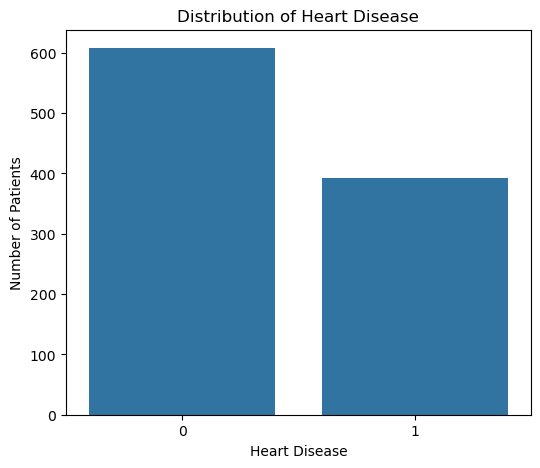

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Heart Disease')

plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')

plt.show()

### Percentage Distribution

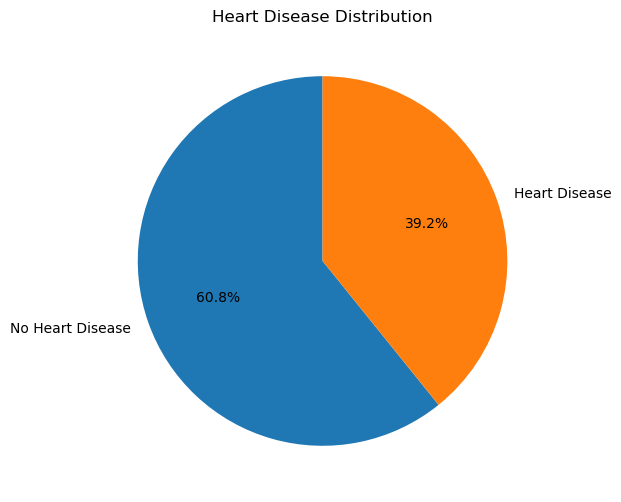

In [37]:
heart_counts = df['Heart Disease'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    heart_counts,
    labels=['No Heart Disease','Heart Disease'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Heart Disease Distribution")

plt.show()

### Age Distribution

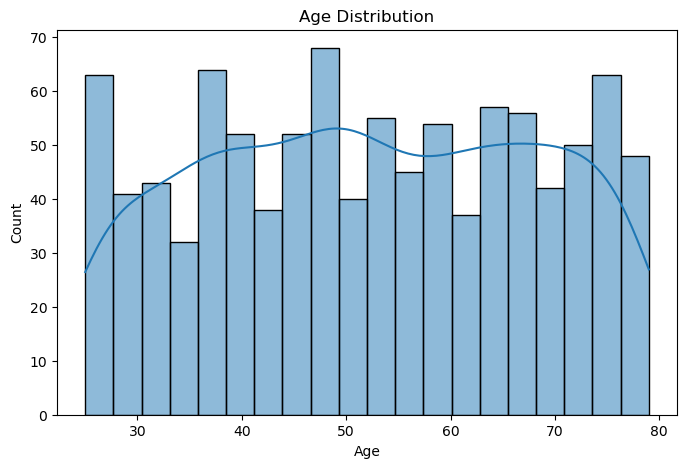

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

### Gender Distribution

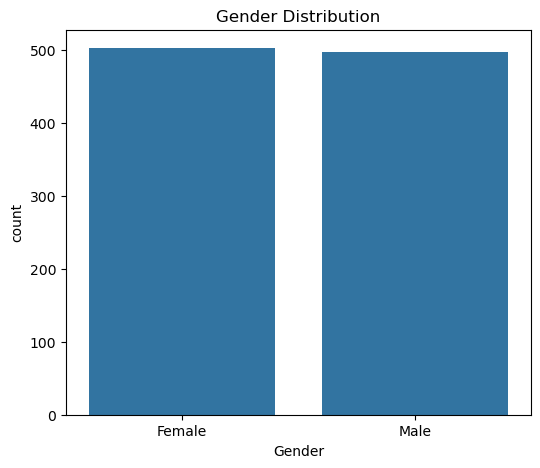

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")

plt.show()

### Heart Disease by Gender

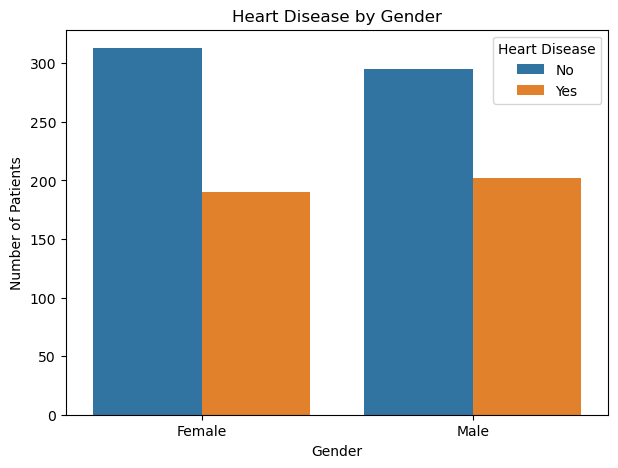

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Heart Disease'
)

plt.title('Heart Disease by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Smoking Status

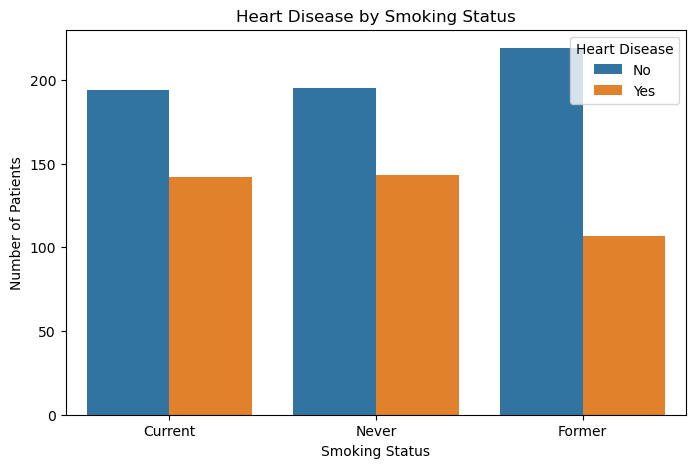

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Smoking',
    hue='Heart Disease'
)

plt.title('Heart Disease by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Alcohol Intake

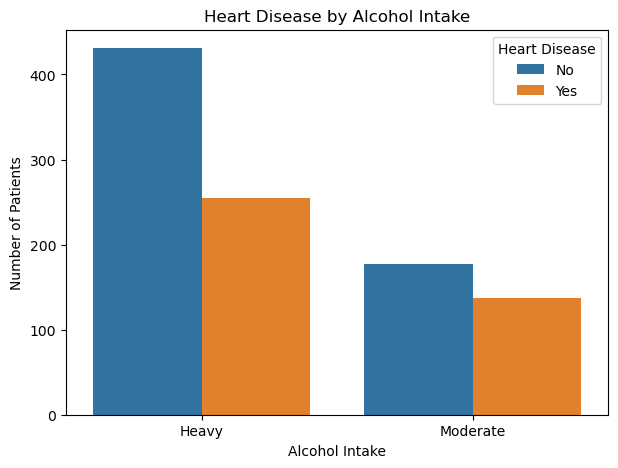

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Alcohol Intake',
    hue='Heart Disease'
)

plt.title('Heart Disease by Alcohol Intake')
plt.xlabel('Alcohol Intake')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Diabetes

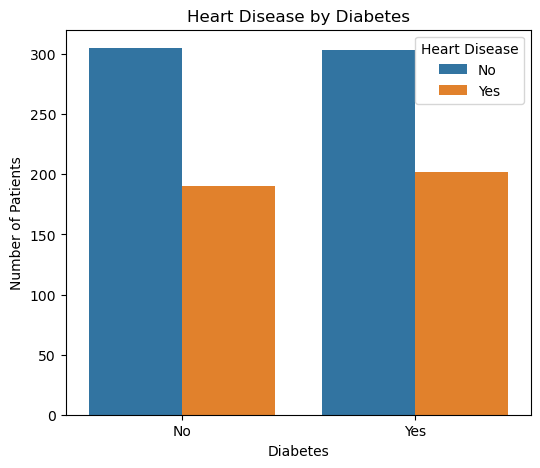

In [43]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Diabetes',
    hue='Heart Disease'
)

plt.title('Heart Disease by Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Obesity

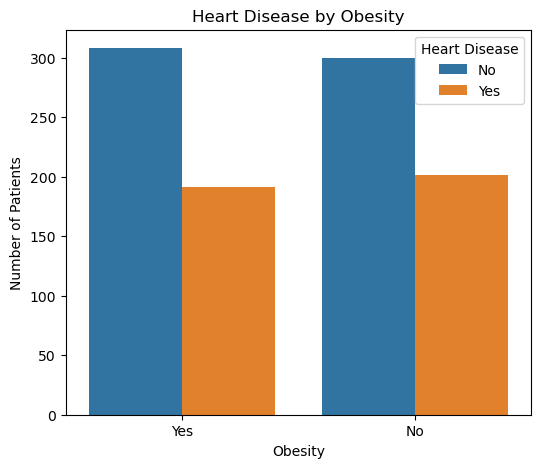

In [44]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Obesity',
    hue='Heart Disease'
)

plt.title('Heart Disease by Obesity')
plt.xlabel('Obesity')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Family History

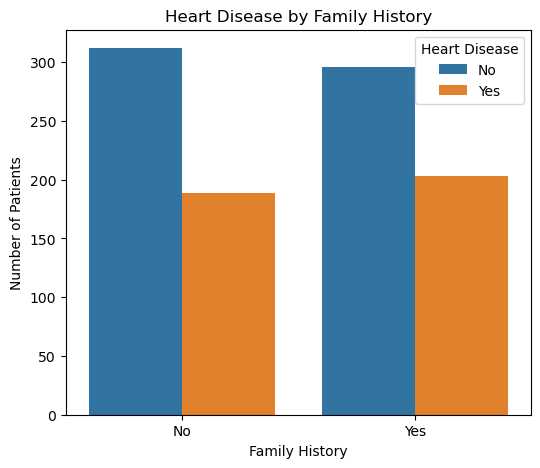

In [45]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Family History',
    hue='Heart Disease'
)

plt.title('Heart Disease by Family History')
plt.xlabel('Family History')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Exercise-Induced Angina

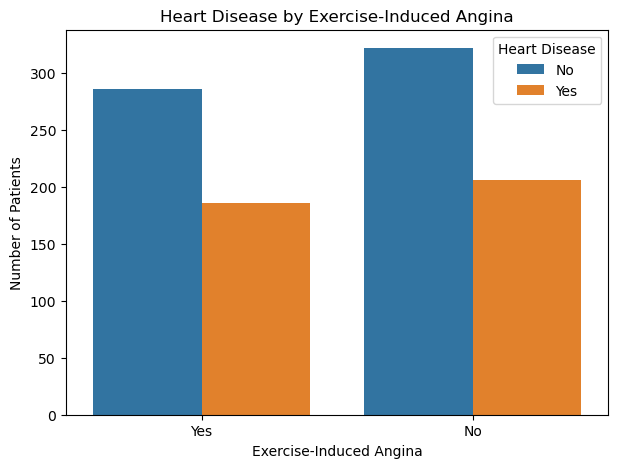

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Exercise Induced Angina',
    hue='Heart Disease'
)

plt.title('Heart Disease by Exercise-Induced Angina')
plt.xlabel('Exercise-Induced Angina')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### Heart Disease by Chest Pain Type

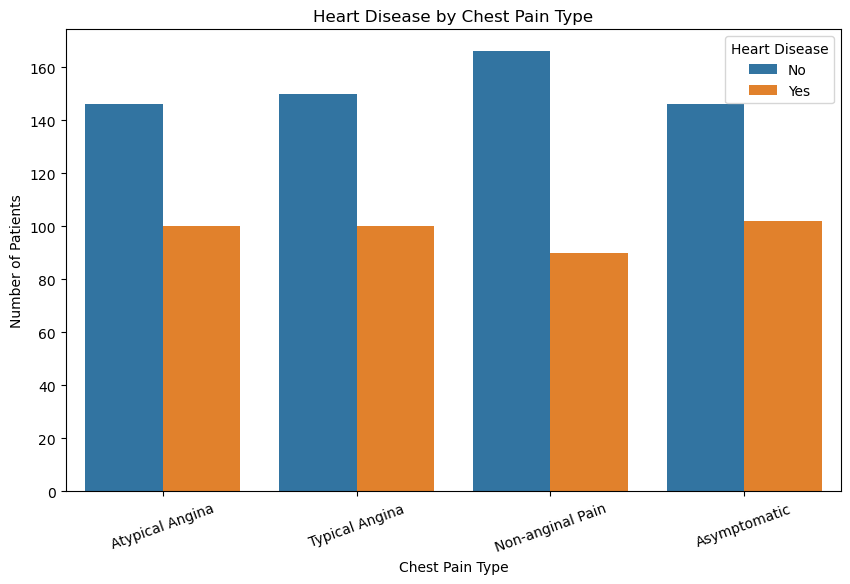

In [47]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Chest Pain Type',
    hue='Heart Disease'
)

plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=20)
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

### percentage of patients with heart disease:

### Smoking

In [48]:
heart_by_smoking = pd.crosstab(
    df['Smoking'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_smoking.round(1)

Heart Disease,0,1
Smoking,,
Current,57.7,42.3
Former,67.2,32.8
Never,57.7,42.3


### Gender

In [50]:
heart_by_gender = pd.crosstab(
    df['Gender'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_gender.round(1)

Heart Disease,0,1
Gender,,
Female,62.2,37.8
Male,59.4,40.6


### Diabetes

In [51]:
heart_by_diabetes = pd.crosstab(
    df['Diabetes'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_diabetes.round(1)

Heart Disease,0,1
Diabetes,,
No,61.6,38.4
Yes,60.0,40.0


### Obesity

In [52]:
heart_by_obesity = pd.crosstab(
    df['Obesity'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_obesity.round(1)

Heart Disease,0,1
Obesity,,
No,59.9,40.1
Yes,61.7,38.3


### Family History

In [53]:
heart_by_family = pd.crosstab(
    df['Family History'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_family.round(1)

Heart Disease,0,1
Family History,,
No,62.3,37.7
Yes,59.3,40.7


### Alcohol Intake

In [54]:
heart_by_alcohol = pd.crosstab(
    df['Alcohol Intake'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_alcohol.round(1)

Heart Disease,0,1
Alcohol Intake,,
Heavy,62.8,37.2
Moderate,56.4,43.6


### Chest Pain Type

In [55]:
heart_by_chest_pain = pd.crosstab(
    df['Chest Pain Type'],
    df['Heart Disease'],
    normalize='index'
) * 100

heart_by_chest_pain.round(1)

Heart Disease,0,1
Chest Pain Type,,
Asymptomatic,58.9,41.1
Atypical Angina,59.3,40.7
Non-anginal Pain,64.8,35.2
Typical Angina,60.0,40.0


### Numerical Columns

In [57]:
numerical_cols = [
    'Age',
    'Cholesterol',
    'Blood Pressure',
    'Heart Rate',
    'Exercise Hours',
    'Stress Level',
    'Blood Sugar'
]

### Age Distribution  

In [59]:
# Histogram

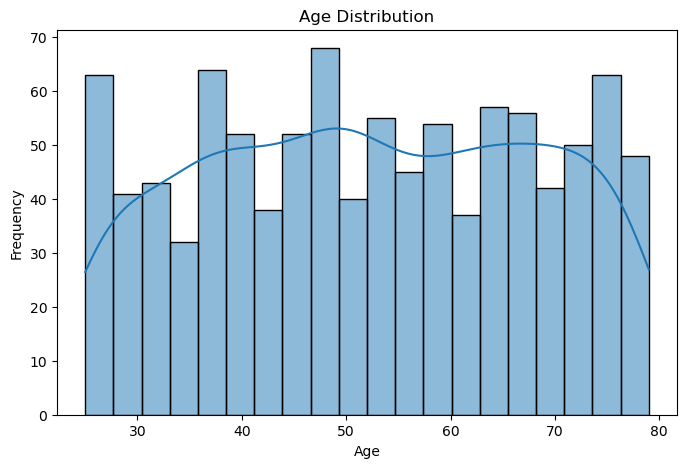

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# Boxplot

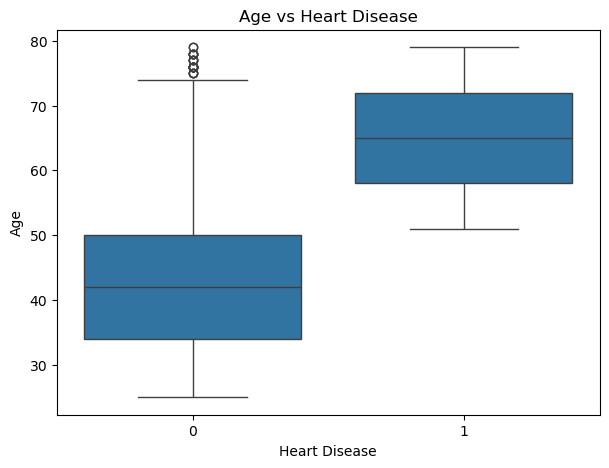

In [60]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Heart Disease', y='Age')

plt.title('Age vs Heart Disease')

plt.show()

### Cholesterol

In [ ]:
# Histogram

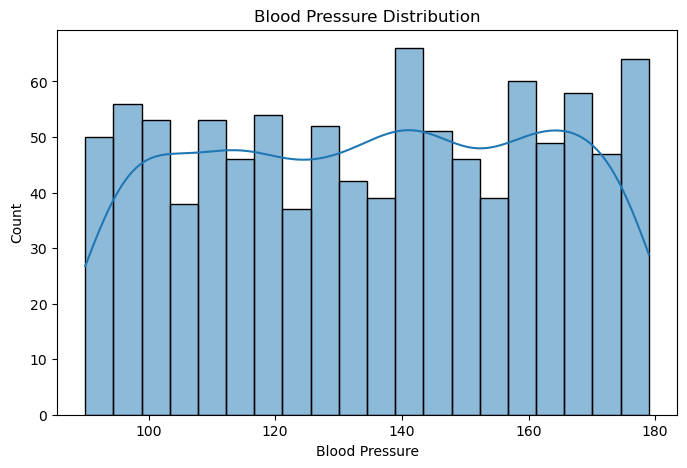

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(df['Blood Pressure'], bins=20, kde=True)

plt.title('Blood Pressure Distribution')

plt.show()

In [62]:
# Boxplot

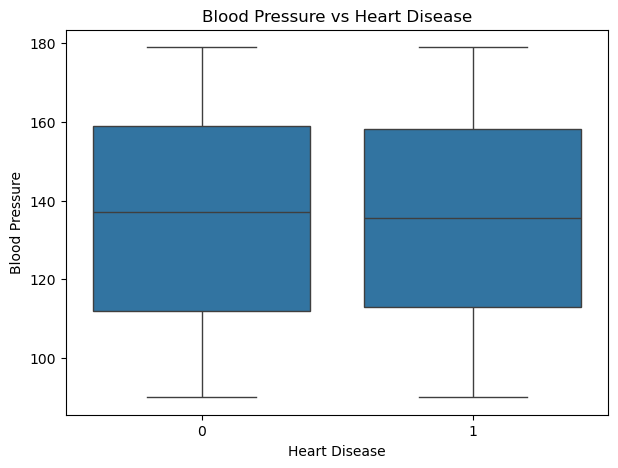

In [63]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Heart Disease', y='Blood Pressure')

plt.title('Blood Pressure vs Heart Disease')

plt.show()

### Heart Rate

In [ ]:
# Histogram

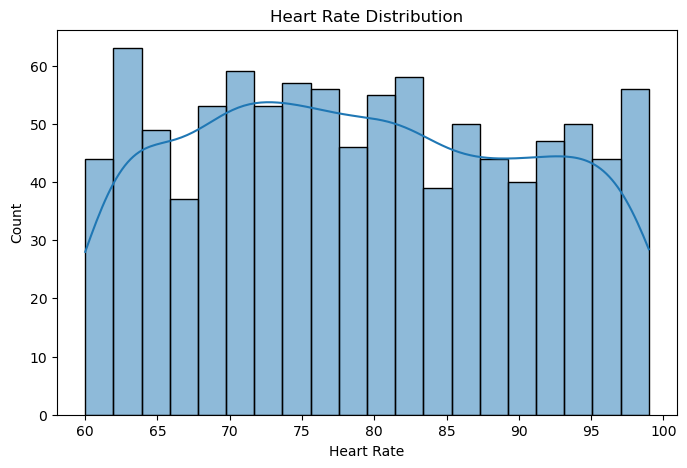

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(df['Heart Rate'], bins=20, kde=True)

plt.title('Heart Rate Distribution')

plt.show()

In [65]:
# Boxplot

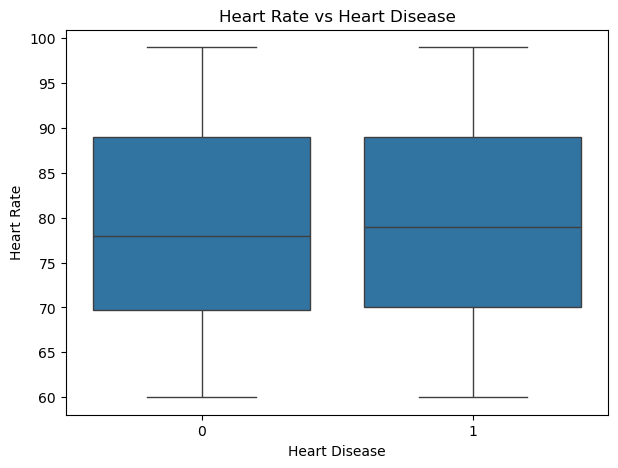

In [66]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Heart Disease', y='Heart Rate')

plt.title('Heart Rate vs Heart Disease')

plt.show()

### Exercise Hours

In [67]:
# Histogram

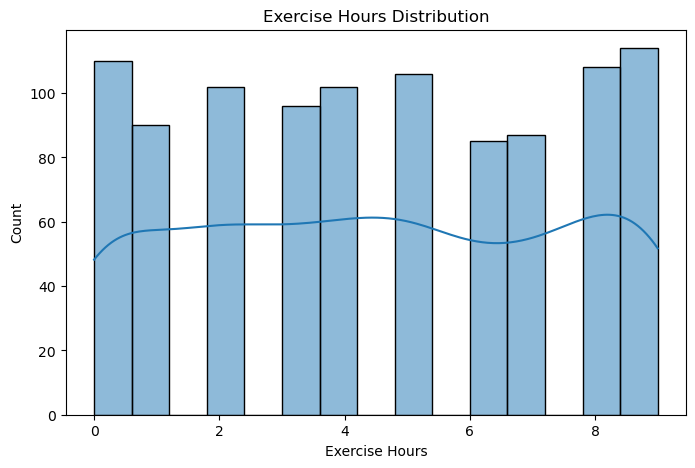

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(df['Exercise Hours'], bins=15, kde=True)

plt.title('Exercise Hours Distribution')

plt.show()

In [ ]:
# Boxplot

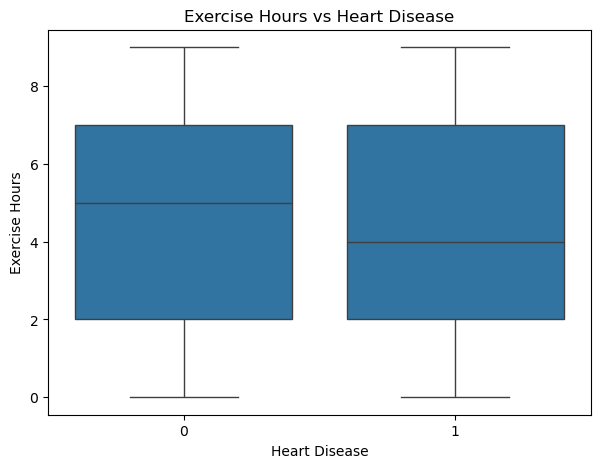

In [69]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Heart Disease', y='Exercise Hours')

plt.title('Exercise Hours vs Heart Disease')

plt.show()

### Stress Level

In [ ]:
# Histogram

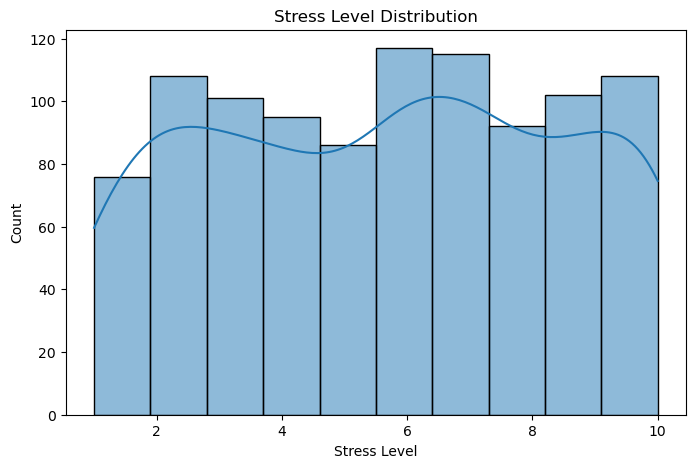

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(df['Stress Level'], bins=10, kde=True)

plt.title('Stress Level Distribution')

plt.show()

In [ ]:
# Boxplot

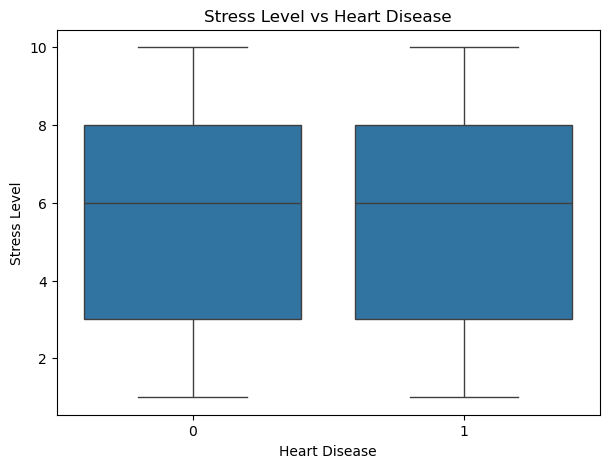

In [72]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Heart Disease', y='Stress Level')

plt.title('Stress Level vs Heart Disease')

plt.show()

### Blood Sugar

In [ ]:
# Histogram

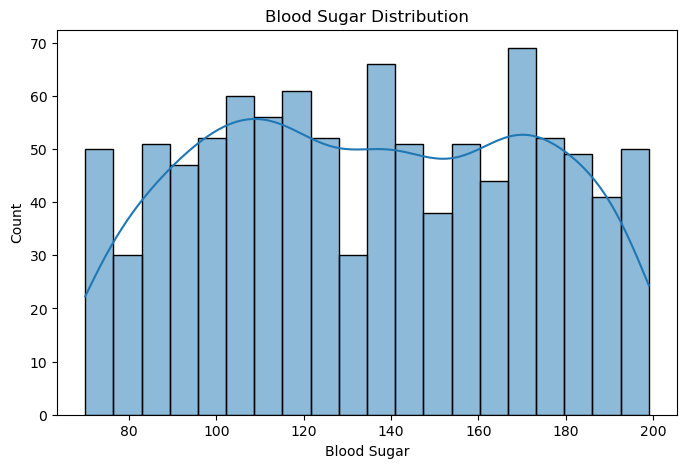

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(df['Blood Sugar'], bins=20, kde=True)

plt.title('Blood Sugar Distribution')

plt.show()

In [ ]:
# Boxplot

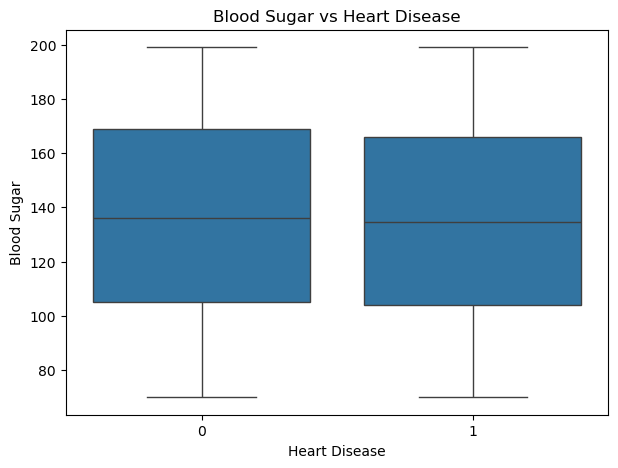

In [74]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Heart Disease', y='Blood Sugar')

plt.title('Blood Sugar vs Heart Disease')

plt.show()

### Professional Summary Table

In [75]:
numerical_summary = (
    df.groupby('Heart Disease')[numerical_cols]
      .mean()
      .round(2)
)

numerical_summary

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar
Heart Disease,,,,,,,
0,44.13,232.97,135.13,79.08,4.56,5.63,135.32
1,64.96,276.26,135.51,79.39,4.48,5.67,134.35


### Advanced EDA

#### Correlation Heatmap (Numerical Features)

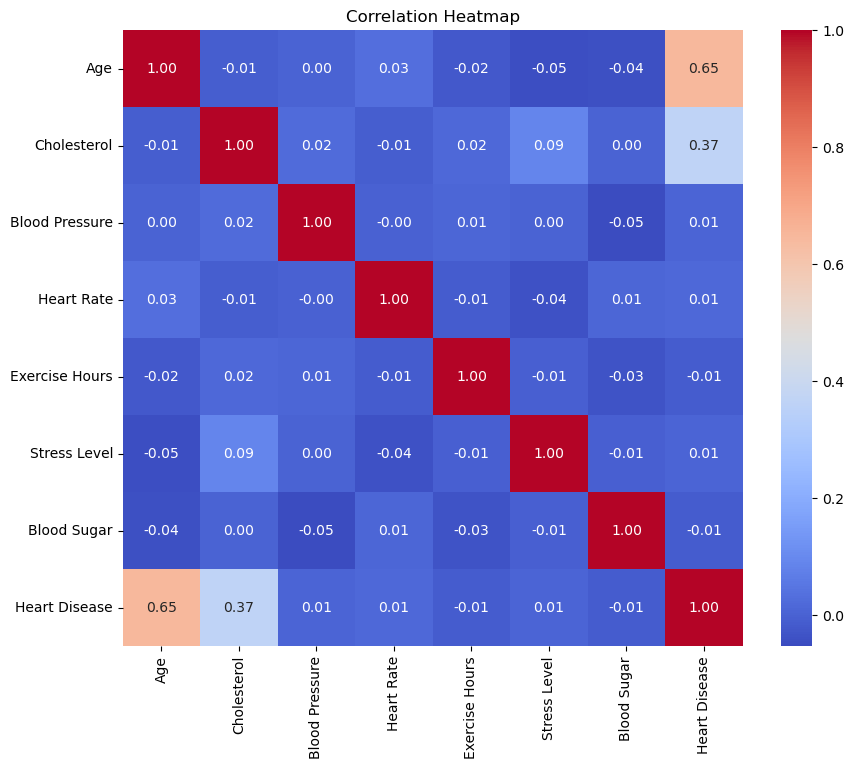

In [77]:
plt.figure(figsize=(10,8))

correlation = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

#### Correlation with Heart Disease

In [79]:
correlation_target = (
    df.select_dtypes(include=['int64', 'float64'])
      .corr()['Heart Disease']
      .sort_values(ascending=False)
)

correlation_target

Heart Disease     1.000000
Age               0.646871
Cholesterol       0.365041
Heart Rate        0.013209
Stress Level      0.007071
Blood Pressure    0.006900
Blood Sugar      -0.013004
Exercise Hours   -0.014226
Name: Heart Disease, dtype: float64

In [ ]:
# Bar Chart

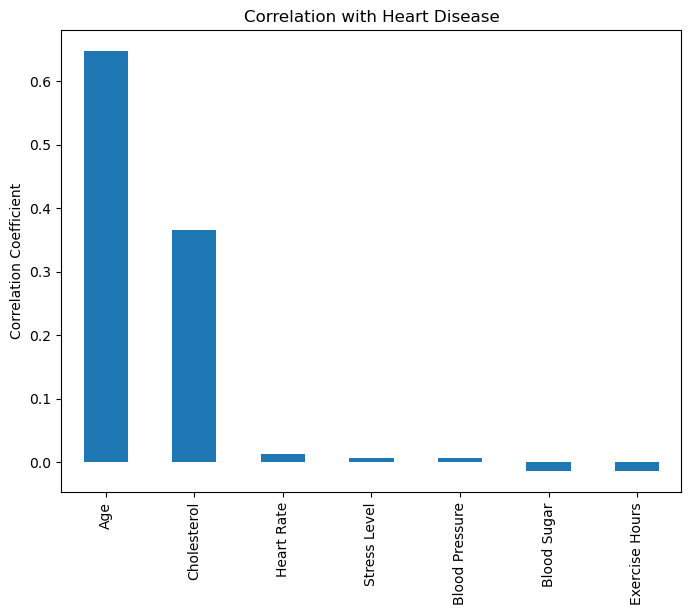

In [80]:
plt.figure(figsize=(8,6))

correlation_target.drop('Heart Disease').plot(kind='bar')

plt.title("Correlation with Heart Disease")
plt.ylabel("Correlation Coefficient")

plt.show()

#### Correlation Matrix Table

In [82]:
correlation.round(2)

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
Age,1.00,-0.01,0.00,0.03,-0.02,-0.05,-0.04,0.65
Cholesterol,-0.01,1.00,0.02,-0.01,0.02,0.09,0.00,0.37
Blood Pressure,0.00,0.02,1.00,-0.00,0.01,0.00,-0.05,0.01
Heart Rate,0.03,-0.01,-0.00,1.00,-0.01,-0.04,0.01,0.01
Exercise Hours,-0.02,0.02,0.01,-0.01,1.00,-0.01,-0.03,-0.01
Stress Level,-0.05,0.09,0.00,-0.04,-0.01,1.00,-0.01,0.01
Blood Sugar,-0.04,0.00,-0.05,0.01,-0.03,-0.01,1.00,-0.01
Heart Disease,0.65,0.37,0.01,0.01,-0.01,0.01,-0.01,1.00


#### Pairplot (Selected Features)

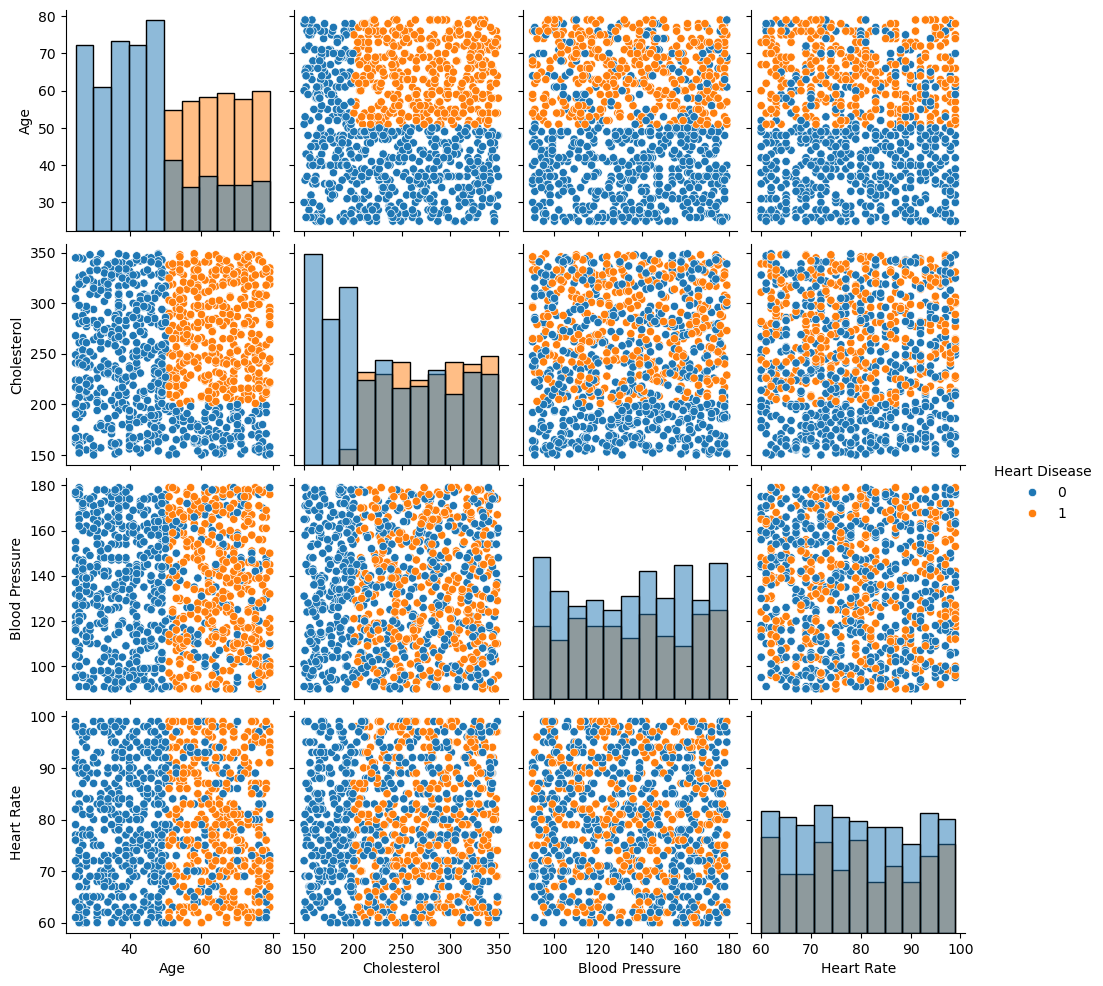

In [83]:
selected_features = [
    'Age',
    'Cholesterol',
    'Blood Pressure',
    'Heart Rate',
    'Heart Disease'
]

sns.pairplot(
    df[selected_features],
    hue='Heart Disease',
    diag_kind='hist'
)

plt.show()

#### Outlier Detection

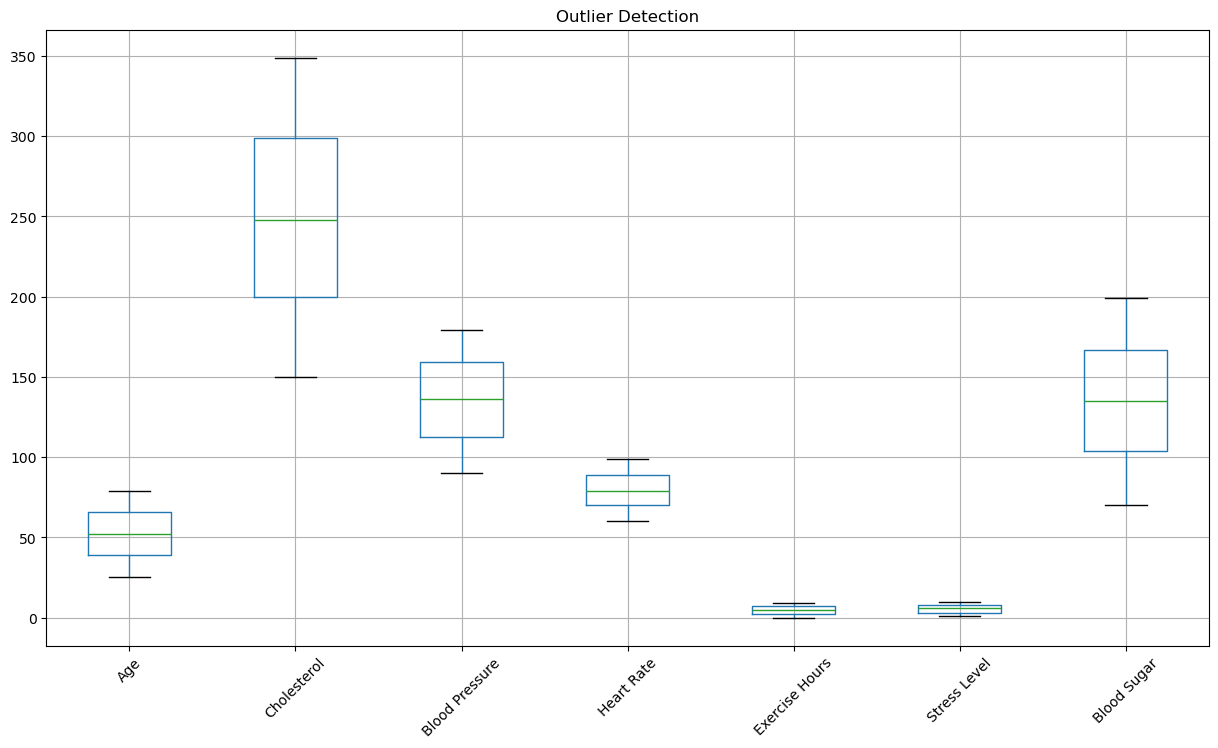

In [84]:
plt.figure(figsize=(15,8))

df[numerical_cols].boxplot()

plt.xticks(rotation=45)

plt.title("Outlier Detection")

plt.show()

#### Distribution of Numerical Features

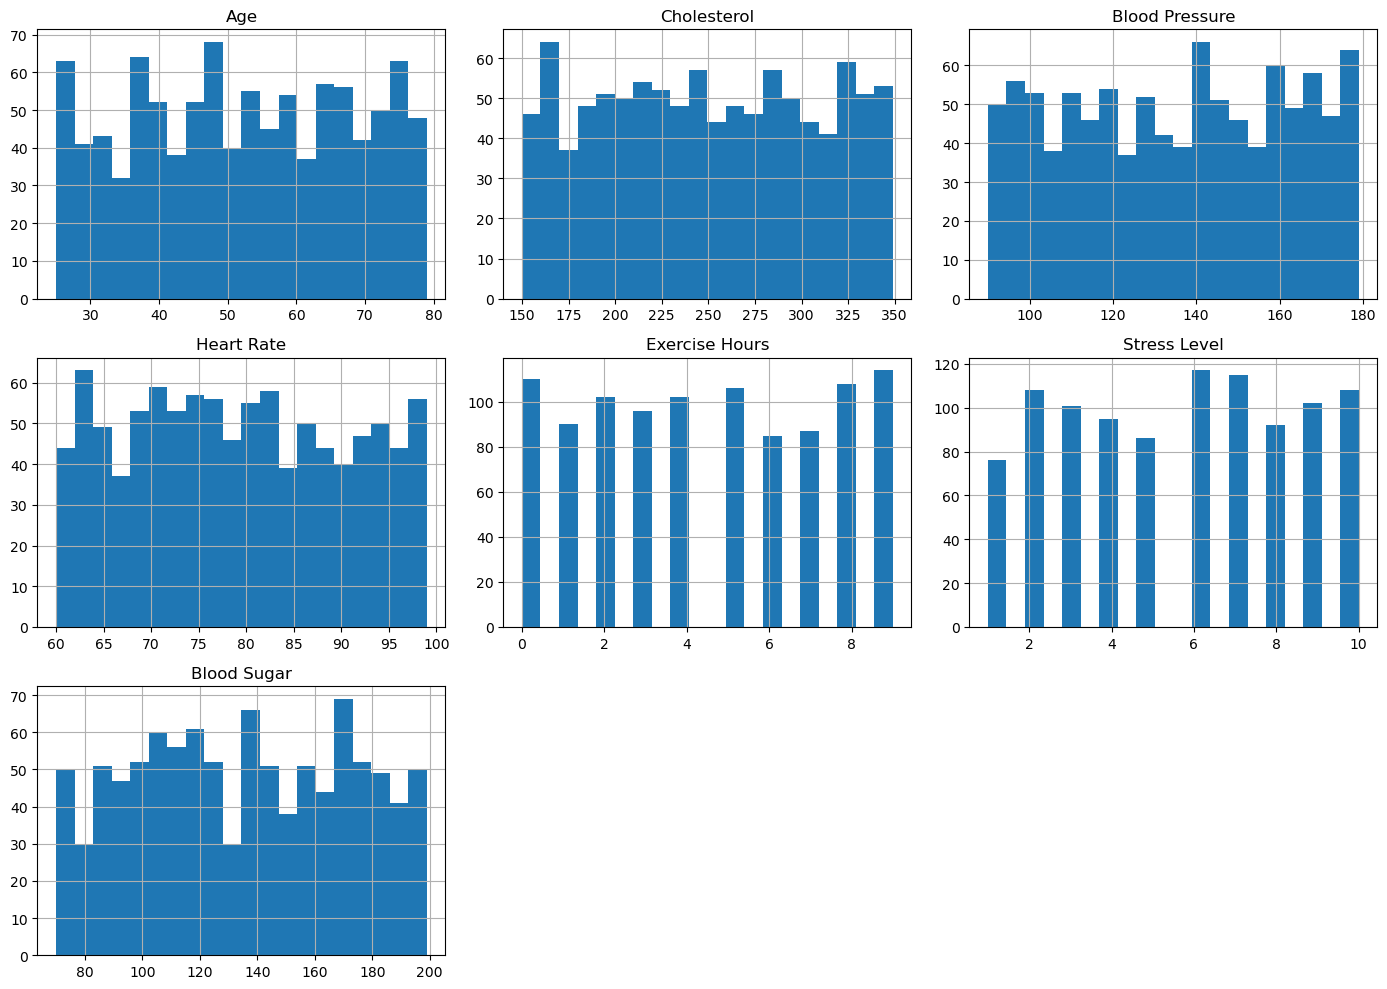

In [85]:
df[numerical_cols].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()

plt.show()

#### Summary Statistics

In [86]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,52.293,15.727126,25.0,39.00,52.0,66.0,79.0
Cholesterol,1000.0,249.939,57.914673,150.0,200.00,248.0,299.0,349.0
Blood Pressure,1000.0,135.281,26.388300,90.0,112.75,136.0,159.0,179.0
Heart Rate,1000.0,79.204,11.486092,60.0,70.00,79.0,89.0,99.0
Exercise Hours,1000.0,4.529,2.934241,0.0,2.00,4.5,7.0,9.0
Stress Level,1000.0,5.646,2.831024,1.0,3.00,6.0,8.0,10.0
Blood Sugar,1000.0,134.941,36.699624,70.0,104.00,135.0,167.0,199.0


#### Categorical Summary

In [87]:
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(df[col].value_counts())


Gender
Gender
Female    503
Male      497
Name: count, dtype: int64

Smoking
Smoking
Never      338
Current    336
Former     326
Name: count, dtype: int64

Alcohol Intake
Alcohol Intake
Heavy       686
Moderate    314
Name: count, dtype: int64

Family History
Family History
No     501
Yes    499
Name: count, dtype: int64

Diabetes
Diabetes
Yes    505
No     495
Name: count, dtype: int64

Obesity
Obesity
No     501
Yes    499
Name: count, dtype: int64

Exercise Induced Angina
Exercise Induced Angina
No     528
Yes    472
Name: count, dtype: int64

Chest Pain Type
Chest Pain Type
Non-anginal Pain    256
Typical Angina      250
Asymptomatic        248
Atypical Angina     246
Name: count, dtype: int64


### Data Preprocessing & Feature Engineering

#### Separate Features and Target

In [88]:
# Features
X = df.drop("Heart Disease", axis=1)

# Target
y = df["Heart Disease"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 15)
Target Shape: (1000,)


### Identify Numerical and Categorical Columns

In [89]:
# Numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar']

Categorical Columns:
['Gender', 'Smoking', 'Alcohol Intake', 'Family History', 'Diabetes', 'Obesity', 'Exercise Induced Angina', 'Chest Pain Type']


### Encode Categorical Variables

In [90]:
# One-Hot Encode categorical variables
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X.head()

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Gender_Male,Smoking_Former,Smoking_Never,Alcohol Intake_Moderate,Family History_Yes,Diabetes_Yes,Obesity_Yes,Exercise Induced Angina_Yes,Chest Pain Type_Atypical Angina,Chest Pain Type_Non-anginal Pain,Chest Pain Type_Typical Angina
0,75,228,119,66,1,8,119,False,False,False,False,False,False,True,True,True,False,False
1,48,204,165,62,5,9,70,True,False,False,False,False,False,False,True,False,False,True
2,53,234,91,67,3,5,196,True,False,True,False,True,False,True,True,True,False,False
3,69,192,90,72,4,7,107,False,False,False,False,False,True,False,True,False,True,False
4,62,172,163,93,6,2,183,False,False,True,False,False,True,False,True,False,False,False


### Check the New Shape

In [91]:
print("New Feature Shape:", X.shape)

New Feature Shape: (1000, 18)


### Save Feature Name

In [92]:
feature_names = X.columns.tolist()

print(feature_names)

['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar', 'Gender_Male', 'Smoking_Former', 'Smoking_Never', 'Alcohol Intake_Moderate', 'Family History_Yes', 'Diabetes_Yes', 'Obesity_Yes', 'Exercise Induced Angina_Yes', 'Chest Pain Type_Atypical Angina', 'Chest Pain Type_Non-anginal Pain', 'Chest Pain Type_Typical Angina']


### Train-Test Split

In [ ]:
# We'll use an 80/20 split.

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (800, 18)
Testing Set: (200, 18)


### Feature Scaling

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Verify Scaling

In [96]:
print(X_train_scaled[:5])

[[-0.46711714 -1.49995312 -1.06398834  0.48325774 -0.4899093   0.48887745
  -0.64477572 -0.99252792 -0.69388867 -0.72977192 -0.66832224  0.97043679
  -1.03304572  1.01257911  1.05925253 -0.56772709  1.71490137 -0.57350122]
 [ 1.52129775  0.06518544 -0.30209193 -0.12625653 -0.15262235  0.8457223
   1.2635505   1.00752834 -0.69388867 -0.72977192  1.4962842   0.97043679
   0.96801137 -0.98757716  1.05925253 -0.56772709 -0.58312392  1.74367544]
 [-1.62168063 -0.05520983  0.91694233 -0.38747693 -0.82719625 -0.22481226
  -1.13548818 -0.99252792 -0.69388867  1.37029115 -0.66832224 -1.03046381
   0.96801137  1.01257911 -0.94406194 -0.56772709 -0.58312392  1.74367544]
 [-1.68582305 -1.58594974  1.52645947 -1.08406466 -0.15262235  0.8457223
   0.80009985  1.00752834 -0.69388867 -0.72977192  1.4962842  -1.03046381
   0.96801137 -0.98757716 -0.94406194 -0.56772709 -0.58312392  1.74367544]
 [ 0.68744634  0.40917194 -1.25446245 -1.34528506  0.52195156  1.20256715
  -0.86287015  1.00752834 -0.6938886

#### Save the Scaler

In [97]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


#### Save Feature Names

In [98]:
joblib.dump(feature_names, "models/feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


### Verify Saved Files

In [99]:
import os

print(os.listdir("models"))

['feature_names.pkl', 'Hospital Readmission Risk Prediction - Copy.ipynb', 'Hospital Readmission Risk Prediction.ipynb', 'hospital_readmission_risk_dataset_2026_v1_18000rows (1).csv', 'random_forest_readmission_model.pkl', 'scaler.pkl']


### Machine Learning


In [101]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

#### Logistic Regression

# Train Logistic Regression

log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

### Make Predictions

In [104]:
# Predictions

y_pred_lr = log_reg.predict(X_test_scaled)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]

### Evaluate the Model

In [106]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.86
Precision: 0.8472222222222222
Recall   : 0.782051282051282
F1 Score : 0.8133333333333334
ROC AUC  : 0.9508196721311475


### Classification Report

In [107]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       122
           1       0.85      0.78      0.81        78

    accuracy                           0.86       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.86      0.86       200



### Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

#### ROC Curve

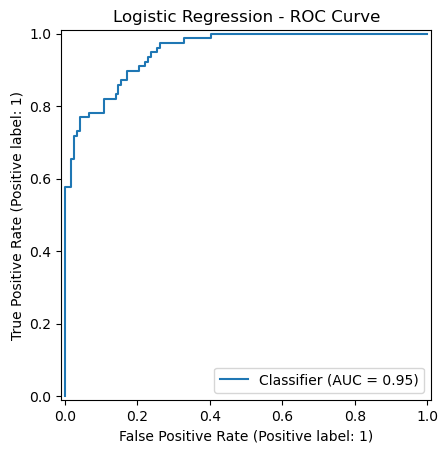

In [109]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

#### Decision Tree

In [110]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### Predictions

In [112]:
y_pred_dt = dt.predict(X_test)

y_prob_dt = dt.predict_proba(X_test)[:,1]

##### Evaluation

In [113]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


### Random Forest

In [114]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Predictions

In [115]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

##### Evaluation

In [116]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.995
Precision: 1.0
Recall   : 0.9871794871794872
F1 Score : 0.9935483870967742
ROC AUC  : 1.0


### Gradient Boosting

In [117]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


##### Predictions

In [118]:
y_pred_gb = gb.predict(X_test)

y_prob_gb = gb.predict_proba(X_test)[:,1]

##### Evaluation

In [119]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_gb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


### Professional Model Comparison

In [120]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

results = results.sort_values(
    by="ROC AUC",
    ascending=False
)

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,0.995,1.0000,0.9872,0.9935,1.0000
3,Gradient Boosting,1.000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression,0.860,0.8472,0.7821,0.8133,0.9508


### Visual Comparison

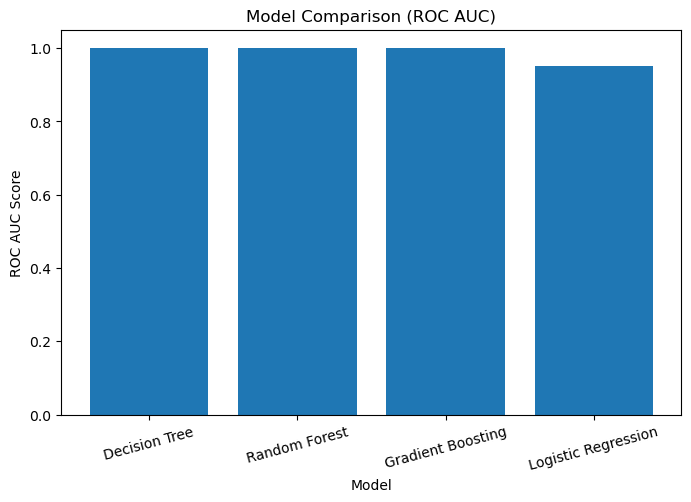

In [121]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["ROC AUC"])

plt.title("Model Comparison (ROC AUC)")
plt.xlabel("Model")
plt.ylabel("ROC AUC Score")
plt.xticks(rotation=15)

plt.show()

### Let's check for data leakage

In [123]:
# Check correlations with the target
corr = df.select_dtypes(include=['int64', 'float64']).corr()

print(corr['Heart Disease'].sort_values(ascending=False))

Heart Disease     1.000000
Age               0.646871
Cholesterol       0.365041
Heart Rate        0.013209
Stress Level      0.007071
Blood Pressure    0.006900
Blood Sugar      -0.013004
Exercise Hours   -0.014226
Name: Heart Disease, dtype: float64


### Let's perform one more professional check

In [124]:
categorical_cols = [
    'Gender',
    'Smoking',
    'Alcohol Intake',
    'Family History',
    'Diabetes',
    'Obesity',
    'Exercise Induced Angina',
    'Chest Pain Type'
]

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)
    print(pd.crosstab(df[col], df['Heart Disease']))


Gender
Heart Disease    0    1
Gender                 
Female         313  190
Male           295  202

Smoking
Heart Disease    0    1
Smoking                
Current        194  142
Former         219  107
Never          195  143

Alcohol Intake
Heart Disease     0    1
Alcohol Intake          
Heavy           431  255
Moderate        177  137

Family History
Heart Disease     0    1
Family History          
No              312  189
Yes             296  203

Diabetes
Heart Disease    0    1
Diabetes               
No             305  190
Yes            303  202

Obesity
Heart Disease    0    1
Obesity                
No             300  201
Yes            308  191

Exercise Induced Angina
Heart Disease              0    1
Exercise Induced Angina          
No                       322  206
Yes                      286  186

Chest Pain Type
Heart Disease       0    1
Chest Pain Type           
Asymptomatic      146  102
Atypical Angina   146  100
Non-anginal Pain  166   90
Typical Ang

One More Check (Recommended)

Let's compare training accuracy and testing accuracy. This helps determine whether the models are overfitting.

Run this for the Decision Tree:

In [125]:
from sklearn.metrics import accuracy_score

# Training predictions
y_train_pred_dt = dt.predict(X_train)

# Testing predictions
y_test_pred_dt = dt.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Testing Accuracy :", accuracy_score(y_test, y_test_pred_dt))

Training Accuracy: 1.0
Testing Accuracy : 1.0


In [126]:
# Training predictions
y_train_pred_rf = rf.predict(X_train)

# Testing predictions
y_test_pred_rf = rf.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy :", accuracy_score(y_test, y_test_pred_rf))

Training Accuracy: 1.0
Testing Accuracy : 0.995


### Feature Importance

In [127]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Age,0.539959
1,Cholesterol,0.280327
6,Blood Sugar,0.031812
2,Blood Pressure,0.031232
3,Heart Rate,0.027810
4,Exercise Hours,0.018325
5,Stress Level,0.017647
8,Smoking_Former,0.006039
10,Alcohol Intake_Moderate,0.005592
12,Diabetes_Yes,0.005591


##### Then create the chart:

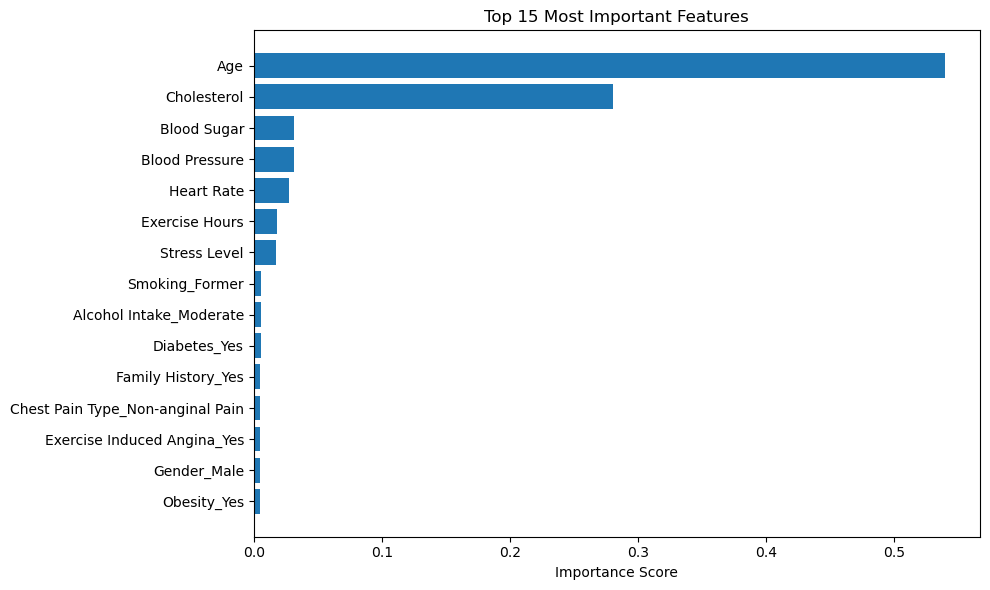

In [128]:
import matplotlib.pyplot as plt

top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(top15["Feature"], top15["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

### Save your trained Random Forest mode

##### Import the Required Libraries

In [129]:
import joblib
import os

#### Create a models Folder

In [130]:
# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

#### Save the Random Forest Model

In [132]:
# Save the trained Random Forest model
joblib.dump(rf, "models/heart_disease_model.pkl")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


#### Save the Scaler

In [133]:
joblib.dump(scaler, "models/scaler.pkl")

print("✅ Scaler saved successfully!")

✅ Scaler saved successfully!


#### Save the Feature Names

In [134]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "models/feature_names.pkl")

print("✅ Feature names saved successfully!")

✅ Feature names saved successfully!


#### Verify the Saved Files

In [135]:
import os

print(os.listdir("models"))

['feature_names.pkl', 'heart_disease_model.pkl', 'Hospital Readmission Risk Prediction - Copy.ipynb', 'Hospital Readmission Risk Prediction.ipynb', 'hospital_readmission_risk_dataset_2026_v1_18000rows (1).csv', 'random_forest_readmission_model.pkl', 'scaler.pkl']


#### Test That the Model Loads Correctly

In [137]:
# Load the saved model
loaded_model = joblib.load("models/heart_disease_model.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
